# Predicting Customer Subscription to Bank Term Deposits Using Machine Learning

In [2]:
pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 

In [5]:
type(X)

pandas.core.frame.DataFrame

In [6]:
type(y)

pandas.core.frame.DataFrame

In [8]:
X.head()


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [9]:
y.head()

,y
0,no
1,no
2,no
3,no
4,no


In [11]:
import pandas as pd
# join features(X) and (y) target into a single dataframe
data = pd.concat([X, y], axis=1)
data.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


## exploratory Data analysis

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [13]:
data.drop(columns=["poutcome"]) # removing the coloum due to large no of null values 

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,no


In [15]:
data['contact'].value_counts(normalize=True) * 100


contact
cellular     90.972632
telephone     9.027368
Name: proportion, dtype: float64

In [16]:
data['contact'].value_counts()


contact
cellular     29285
telephone     2906
Name: count, dtype: int64

most of the customers are contacted using cellular, so we are going to assume that customer with no information for this coloumn were also contacted using the cellular phones 

In [19]:
data["contact"].isnull().any() # confirmed that null values have been removed

True

In [22]:
most_job_type = "cellular"
data["job"].isnull().any()

True

In [20]:
data['job'].value_counts(normalize=True) * 100


job
blue-collar      21.663736
management       21.053803
technician       16.911159
admin.           11.510807
services          9.246934
retired           5.039735
self-employed     3.514903
entrepreneur      3.310108
unemployed        2.900519
housemaid         2.760279
student           2.088017
Name: proportion, dtype: float64

In [ ]:
data["contact"].isnull().any() # confirmed that null values have been removed

In [21]:
most_job_type = "blue-collar"
data["job"].isnull().any()

True

In [ ]:
data_education_type = "secondary"
data["education"] = data["education"].fillna()

In [23]:
data_clean = data.copy()

In [24]:
data_clean.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

In [25]:
for col in data_clean.columns:
    print(col, data_clean[col].value_counts().head(), "\n")

age age
32    2085
31    1996
33    1972
34    1930
35    1894
Name: count, dtype: int64 

job job
blue-collar    9732
management     9458
technician     7597
admin.         5171
services       4154
Name: count, dtype: int64 

marital marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64 

education education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64 

default default
no     44396
yes      815
Name: count, dtype: int64 

balance balance
0    3514
1     195
2     156
4     139
3     134
Name: count, dtype: int64 

housing housing
yes    25130
no     20081
Name: count, dtype: int64 

loan loan
no     37967
yes     7244
Name: count, dtype: int64 

contact contact
cellular     29285
telephone     2906
Name: count, dtype: int64 

day_of_week day_of_week
20    2752
18    2308
21    2026
17    1939
6     1932
Name: count, dtype: int64 

month month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
Name: 

In [26]:
data_clean = data_clean.replace("unknown", "other")

In [27]:
data_clean = data_clean[data_clean != "unknown"]

In [28]:
data_clean.duplicated().sum()

0

In [30]:
data_clean["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [29]:
data_clean.dtypes

age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

In [35]:
from sklearn.model_selection import train_test_split

target_coloumn = "y"
features = data_clean.drop(columns=target_coloumn)
target = data[target_coloumn]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    stratify=target,
    random_state=42
)

In [37]:
len(X_train) == len(y_train)

True

In [38]:
len(X_test) == len(y_test)

True

## preprocessor

In [48]:
from sklearn.compose import make_column_selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder


In [45]:
from sklearn.compose import make_column_selector

numeric_selector = make_column_selector(dtype_include=['int64', 'float64'])
categoric_selector = make_column_selector(dtype_include=['object'])

numeric_columns = numeric_selector(features)
categoric_columns = categoric_selector(features)

In [46]:
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categoric_columns)

Numeric columns: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [49]:
from sklearn.preprocessing import OneHotEncoder

preprocessor_dt = ColumnTransformer(
    [("categoric", OneHotEncoder(handle_unknown='ignore'), categoric_columns)],
    remainder="passthrough"
)

## Model building and training 

### logistic regression

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [56]:
logistic = Pipeline([
    ("preprocessor", preprocessor_dt),
    ("logistic", LogisticRegression(max_iter=1000))
])

In [57]:
logistic.fit(X_train, y_train)

D:\anaconda python\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\anaconda python\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress th

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoric',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('logistic', LogisticRegression(max_iter=1000))])

## train performance

In [58]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score

In [59]:
y_pred_train = logistic.predict(X_train)

In [60]:
balanced_accuracy_train = balanced_accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, pos_label="yes")
recall_train = recall_score(y_train, y_pred_train, pos_label="yes")

In [61]:
print("Train Performance")
print("Accuracy", balanced_accuracy_train)
print("precision", precision_train)
print("recall", recall_train)

Train Performance
Accuracy 0.6552500322163597
precision 0.6471663619744058
recall 0.3346726542188608


In [65]:
y_test_pred = logistic.predict(X_test)

print("Test Performance")
print("Accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, pos_label='yes'))
print("Recall:", recall_score(y_test, y_test_pred, pos_label='yes'))

Test Performance
Accuracy: 0.6560658394224521
Precision: 0.6386404293381037
Recall: 0.33742911153119093


In [66]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_test_pred))


[[7783  202]
 [ 701  357]]


## KNN

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [68]:
preprocessor_knn = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categoric_columns)
    ]
)

In [69]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor_knn),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

In [70]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance',
                                                   'day_of_week', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('knn', KNeighborsClassifier())])

In [71]:
y_test_pred_knn = knn_pipeline.predict(X_test)

In [72]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, confusion_matrix

print("KNN Test Performance")
print("Accuracy:", balanced_accuracy_score(y_test, y_test_pred_knn))
print("Precision:", precision_score(y_test, y_test_pred_knn, pos_label='yes'))
print("Recall:", recall_score(y_test, y_test_pred_knn, pos_label='yes'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_knn))

KNN Test Performance
Accuracy: 0.6550415299006999
Precision: 0.5990016638935108
Recall: 0.34026465028355385

Confusion Matrix:
[[7744  241]
 [ 698  360]]


In [73]:
for k in [3, 5, 7, 9, 11]:
    knn = Pipeline([
        ("preprocessor", preprocessor_knn),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    print(f"k={k}, Recall={recall_score(y_test, y_pred, pos_label='yes')}")

k=3, Recall=0.3648393194706994
k=5, Recall=0.34026465028355385
k=7, Recall=0.33175803402646503
k=9, Recall=0.3383742911153119
k=11, Recall=0.32419659735349715


In [74]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_knn))



Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7985
         yes       0.60      0.34      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.90      0.88      9043


Confusion Matrix:
[[7744  241]
 [ 698  360]]


In [75]:
# Logistic
y_log = logistic.predict(X_test)

# KNN
y_knn = knn_pipeline.predict(X_test)

print("LOGISTIC RECALL:", recall_score(y_test, y_log, pos_label='yes'))
print("KNN RECALL:", recall_score(y_test, y_knn, pos_label='yes'))

LOGISTIC RECALL: 0.33742911153119093
KNN RECALL: 0.34026465028355385


## decision tree classifier

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [79]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor_dt),
    ("dt", DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42))
])

In [80]:
dt_pipeline.fit(X_train, y_train)

D:\anaconda python\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoric',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('dt',
                 DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        random_state=42))])

In [81]:
y_test_pred_dt = dt_pipeline.predict(X_test)

In [82]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, confusion_matrix

print("Decision Tree Test Performance")
print("Accuracy:", balanced_accuracy_score(y_test, y_test_pred_dt))
print("Precision:", precision_score(y_test, y_test_pred_dt, pos_label='yes'))
print("Recall:", recall_score(y_test, y_test_pred_dt, pos_label='yes'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dt))

Decision Tree Test Performance
Accuracy: 0.6417510739062964
Precision: 0.6498993963782697
Recall: 0.3052930056710775

Confusion Matrix:
[[7811  174]
 [ 735  323]]


In [83]:
from sklearn.model_selection import GridSearchCV

In [84]:
param_grid = {
    "dt__max_depth": [3, 5, 7, 10, None],
    "dt__min_samples_split": [2, 5, 10, 20],
    "dt__max_features": [None, "sqrt", "log2"]
}

In [85]:
grid = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [86]:
grid.fit(X_train, y_train)

D:\anaconda python\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(
D:\anaconda python\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('categoric',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['job',
                                                                          'marital',
                                                                          'education',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'month',
                                                                          'poutcome'])])),
                                       ('dt',
                                        DecisionTreeClassifier(max_depth=5,
                                                               min_samples_split=10,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'dt__max_depth': [3, 5, 7, 10, None],
                         'dt__max_features': [None, 'sqrt', 'log2'],
                         'dt__min_samples_split': [2, 5, 10, 20]},
             scoring='recall')

In [89]:
best_dt = grid.best_estimator_

In [90]:
best_dt = grid.best_estimator_

In [91]:
print(best_dt)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoric',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('dt', DecisionTreeClassifier(max_depth=3, random_state=42))])


In [87]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'dt__max_depth': 3, 'dt__max_features': None, 'dt__min_samples_split': 2}


In [92]:
y_test_pred_dt = best_dt.predict(X_test)

print("Optimized Decision Tree")
print("Accuracy:", balanced_accuracy_score(y_test, y_test_pred_dt))
print("Precision:", precision_score(y_test, y_test_pred_dt, pos_label='yes'))
print("Recall:", recall_score(y_test, y_test_pred_dt, pos_label='yes'))


Optimized Decision Tree
Accuracy: 0.6599150936361065
Precision: 0.6295025728987993
Recall: 0.34688090737240074


In [93]:
## comparision logistic,knn,decision tree

In [94]:
# Logistic
y_log = logistic.predict(X_test)

# KNN
y_knn = knn_pipeline.predict(X_test)

# Decision Tree (optimized)
y_dt = best_dt.predict(X_test)

In [95]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score

In [96]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, pos_label='yes'))
    print("Recall:", recall_score(y_true, y_pred, pos_label='yes'))

In [105]:
# Logistic
y_log_train = logistic.predict(X_train)

# KNN
y_knn_train = knn_pipeline.predict(X_train)

# Decision Tree
y_dt_train = best_dt.predict(X_train)

In [106]:
print("===== TRAIN PERFORMANCE =====")

evaluate_model("Logistic Regression (Train)", y_train, y_log_train)
evaluate_model("KNN (Train)", y_train, y_knn_train)
evaluate_model("Decision Tree (Train)", y_train, y_dt_train)

===== TRAIN PERFORMANCE =====

Logistic Regression (Train)
Accuracy: 0.6552500322163597
Precision: 0.6471663619744058
Recall: 0.3346726542188608

KNN (Train)
Accuracy: 0.7358421134399652
Precision: 0.7596644784828592
Recall: 0.4923186008035925

Decision Tree (Train)
Accuracy: 0.6681402282428712
Precision: 0.6406836181742392
Recall: 0.36327109430394705


In [107]:
evaluate_model("Logistic Regression", y_test, y_log)
evaluate_model("KNN", y_test, y_knn)
evaluate_model("Decision Tree", y_test, y_dt)


Logistic Regression
Accuracy: 0.6560658394224521
Precision: 0.6386404293381037
Recall: 0.33742911153119093

KNN
Accuracy: 0.6550415299006999
Precision: 0.5990016638935108
Recall: 0.34026465028355385

Decision Tree
Accuracy: 0.6599150936361065
Precision: 0.6295025728987993
Recall: 0.34688090737240074


In [98]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [101]:
dt_model = best_dt.named_steps["dt"]

In [102]:
feature_names = best_dt.named_steps["preprocessor"].get_feature_names_out()

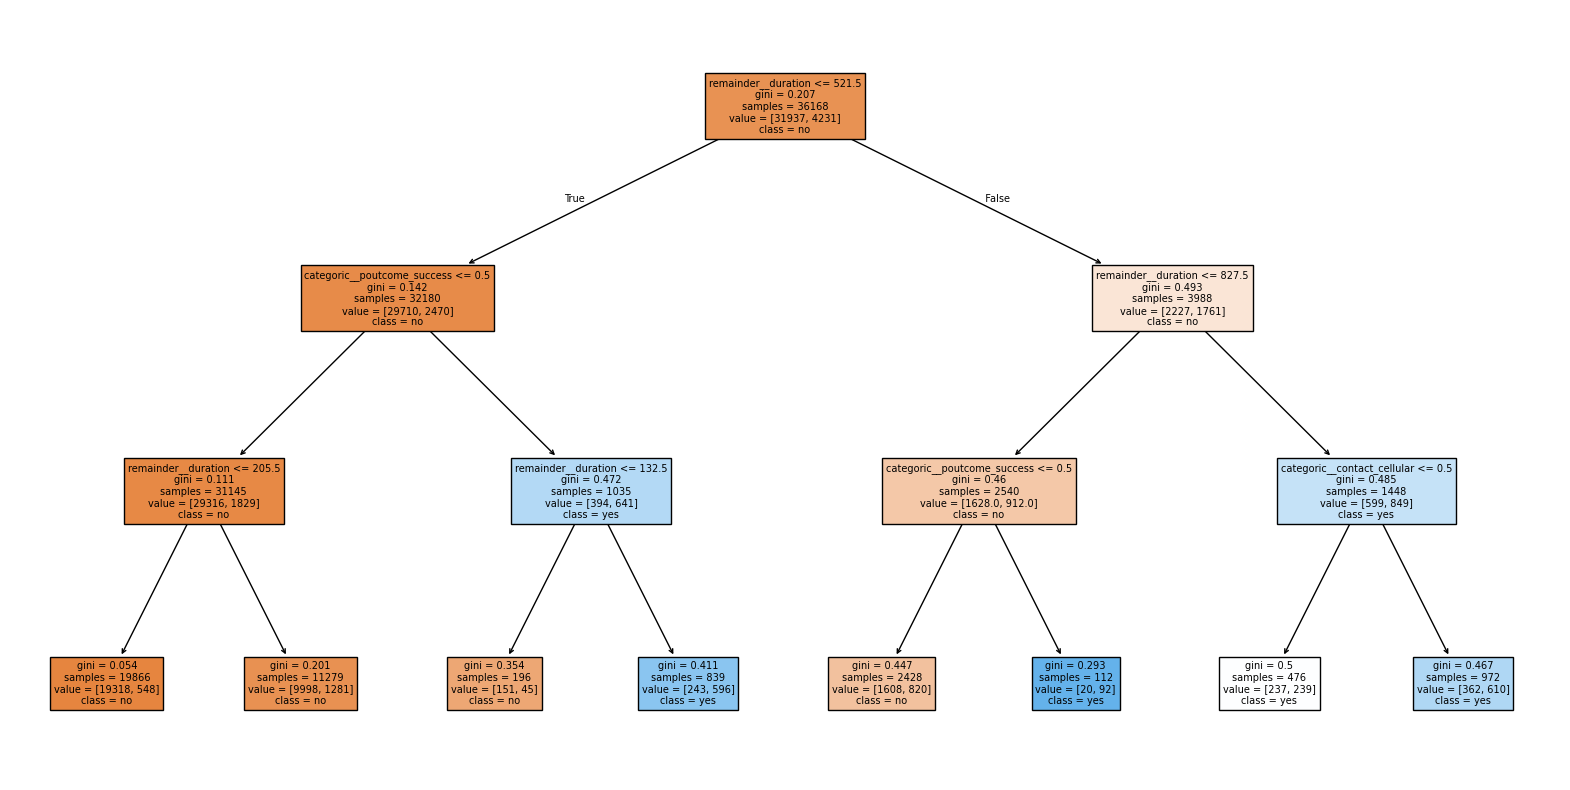

In [103]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    max_depth=3
)
plt.show()

In [109]:
sampled_no = data_clean[data_clean["y"] == "no"].sample(frac=0.15)
yes_only = data_clean[data_clean["y"] == "yes"]

In [110]:
sampled_no.duplicated().any()

False

In [112]:
new_data = pd.concat([sampled_no, yes_only], axis=0)
new_data

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
22340,30,technician,married,secondary,no,398,yes,no,cellular,22,aug,111,2,-1,0,NaN,no
11616,48,blue-collar,married,primary,no,237,yes,no,NaN,19,jun,18,18,-1,0,NaN,no
2534,27,blue-collar,married,secondary,no,0,yes,no,NaN,13,may,296,1,-1,0,NaN,no
7070,26,blue-collar,married,secondary,no,245,yes,no,NaN,28,may,146,2,-1,0,NaN,no
31993,43,blue-collar,divorced,primary,no,515,yes,no,cellular,13,apr,199,2,146,1,failure,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45204,73,retired,married,secondary,no,2850,no,no,cellular,17,nov,300,1,40,8,failure,yes
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,NaN,yes
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes


In [115]:
new_data["y"].value_counts

<bound method IndexOpsMixin.value_counts of 22340     no
11616     no
2534      no
7070      no
31993     no
        ... 
45204    yes
45205    yes
45206    yes
45207    yes
45208    yes
Name: y, Length: 11277, dtype: object>

In [122]:
y_dt_train = best_dt.predict(X_train)

In [123]:
y_dt_test = best_dt.predict(X_test)

In [127]:
y_dt_train = dt_pipeline.predict(X_train)
y_dt_test = dt_pipeline.predict(X_test)

In [128]:
evaluate_model("Decision Tree (Train)", y_train, y_dt_train)


Decision Tree (Train)
Accuracy: 0.6542081892243434
Precision: 0.6986370519939424
Recall: 0.32710943039470575


In [129]:
evaluate_model("Decision Tree (Test)", y_test, y_dt_test)


Decision Tree (Test)
Accuracy: 0.6417510739062964
Precision: 0.6498993963782697
Recall: 0.3052930056710775
